In [1]:
if(!require(pls)){
  install.packages("pls");library(pls)
}
if(!require(plsVarSel)){
  install.packages("plsVarSel");library(plsVarSel)
}

#[1]
ifname <- "DataMerge20211220oh.csv"
readData <- read.delim(ifname, header=T,sep=",",row.names=1,as.is=TRUE,strip.white=FALSE)
nf1<-dim(readData)[2]
charaCheck<-rep(FALSE,nf1)
for(i in 1:nf1){
  charaCheck[i]<-!is.character(readData[,i])
}
readData2<-readData[,charaCheck]
#[2]
yname<-"PCEmax"     #"Jsc","Voc","FF","PCEmax"
Y<-readData2[,yname]
rmlist<-c("Jsc","Voc","FF","PCEmax","PCEcal", "PCEdiff", "PCEave")
collist<-colnames(readData2)
Xnames<-setdiff(collist, rmlist)
X<-readData2[,c(Xnames)]
#---
Nadata<-is.na(X)

Loading required package: pls


Attaching package: 'pls'


The following object is masked from 'package:stats':

    loadings


Loading required package: plsVarSel

Registered S3 method overwritten by 'plsVarSel':
  method       from
  print.mvrVal pls 



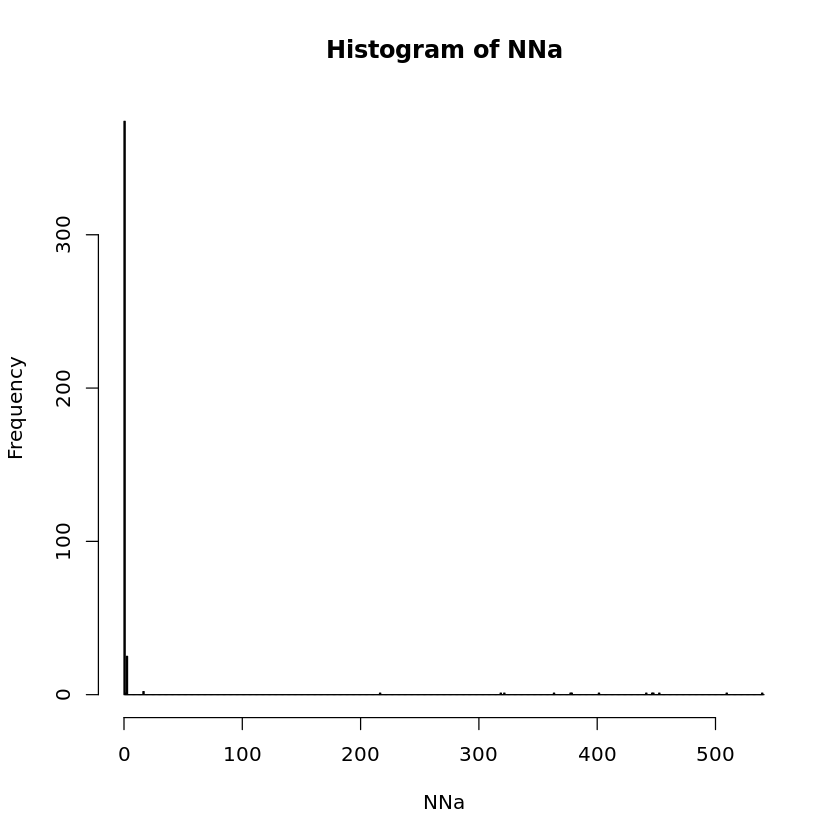

In [2]:
NNa<-apply(Nadata,2,sum)
mNNA<-max(NNa)
hist(NNa,breaks=seq(0,mNNA+1,1))


In [3]:
XX<-X[,NNa==0] #~100 変化
dim(XX)
#---
dMerge<-data.frame(Y,XX)
Nadata<-na.omit(dMerge)
#[3]
sdcheck<-apply(Nadata,2,sd)
TF<-(sdcheck!=0)
ssd<-scale(Nadata[,TF])
ssd[,1]<-Nadata[,1]
#[4]
YXXdata<-data.frame(ssd)
#----------------------------------------------------------------
#aa<-c(567,574,575,576,577,585,586,587)

YXdata<-YXXdata#[-c(aa),] #
YXdata
dim(YXdata)

[1] 1046  374

,Y,amountAditive,cycle,RatioinM,Ratioip1M,Ratioip2M,Ratiop2M,THFSVAafetrI,THFSVAafetrN,Lay2Mname_,...,namessolvent1_DCM,namessolvent1_TCB,namessolvent1_THF,namessolvent1_oDCB,namessolvent2_,namessolvent2_CB,namessolvent2_CF,namessolvent2_DIO,namessolvent2_TCB,namessolvent2_oDCB
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.0066,-0.3727216,-0.05363137,-0.1810035,-0.1740178,-0.06929813,-0.04708948,-0.07595563,-0.03093441,-0.4832624,...,10.72384991,-0.107729,-0.03093441,-0.8259034,0.3375846,-0.07595563,-0.03093441,-0.04376883,-0.04376883,-0.317903
2,0.0240,-0.3727216,18.62796170,-0.1810035,-0.1740178,-0.06929813,-0.04708948,-0.07595563,-0.03093441,-0.4832624,...,10.72384991,-0.107729,-0.03093441,-0.8259034,0.3375846,-0.07595563,-0.03093441,-0.04376883,-0.04376883,-0.317903
3,0.0280,-0.3727216,18.62796170,-0.1810035,-0.1740178,-0.06929813,-0.04708948,-0.07595563,-0.03093441,-0.4832624,...,10.72384991,-0.107729,-0.03093441,-0.8259034,0.3375846,-0.07595563,-0.03093441,-0.04376883,-0.04376883,-0.317903
4,0.1600,-0.3727216,18.62796170,-0.1810035,-0.1740178,-0.06929813,-0.04708948,-0.07595563,-0.03093441,-0.4832624,...,10.72384991,-0.107729,-0.03093441,-0.8259034,0.3375846,-0.07595563,-0.03093441,-0.04376883,-0.04376883,-0.317903
5,0.2500,-0.3727216,-0.05363137,-0.1810035,-0.1740178,-0.06929813,-0.04708948,-0.07595563,-0.03093441,-0.4832624,...,-0.09316086,-0.107729,-0.03093441,-0.8259034,0.3375846,-0.07595563,-0.03093441,-0.04376883,-0.04376883,-0.317903
6,0.7400,-0.3727216,-0.05363137,-0.1810035,-0.1740178,-0.06929813,-0.04708948,-0.07595563,-0.03093441,-0.4832624,...,-0.09316086,-0.107729,-0.03093441,-0.8259034,0.3375846,-0.07595563,-0.03093441,-0.04376883,-0.04376883,-0.317903
7,0.4400,-0.3727216,-0.05363137,-0.1810035,-0.1740178,-0.06929813,-0.04708948,-0.07595563,-0.03093441,-0.4832624,...,-0.09316086,-0.107729,-0.03093441,-0.8259034,0.3375846,-0.07595563,-0.03093441,-0.04376883,-0.04376883,-0.317903
8,0.5300,-0.3727216,-0.05363137,-0.1810035,-0.1740178,-0.06929813,-0.04708948,-0.07595563,-0.03093441,-0.4832624,...,-0.09316086,-0.107729,-0.03093441,-0.8259034,0.3375846,-0.07595563,-0.03093441,-0.04376883,-0.04376883,-0.317903
9,1.5400,-0.3727216,-0.05363137,-0.1810035,-0.1740178,-0.06929813,-0.04708948,-0.07595563,-0.03093441,-0.4832624,...,-0.09316086,-0.107729,-0.03093441,-0.8259034,0.3375846,-0.07595563,-0.03093441,-0.04376883,-0.04376883,-0.317903


[1] 1045  373

[1] "coefficients"    "scores"          "loadings"        "loading.weights"
 [5] "Yscores"         "Yloadings"       "projection"      "Xmeans"         
 [9] "Ymeans"          "fitted.values"   "residuals"       "Xvar"           
[13] "Xtotvar"         "fit.time"        "ncomp"           "method"         
[17] "center"          "validation"      "call"            "terms"          
[21] "model"

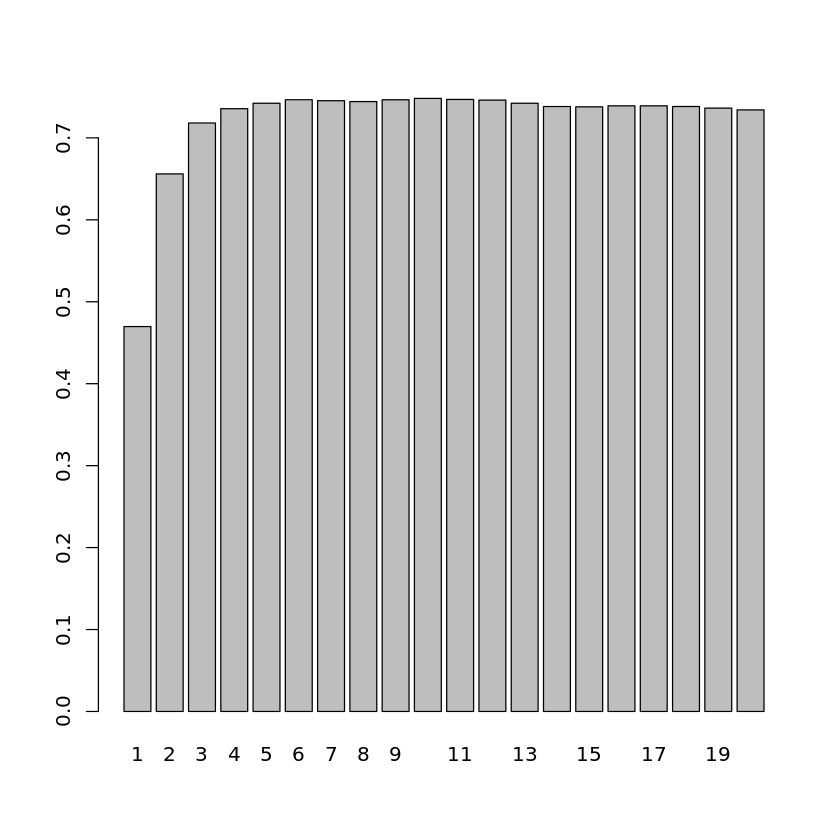

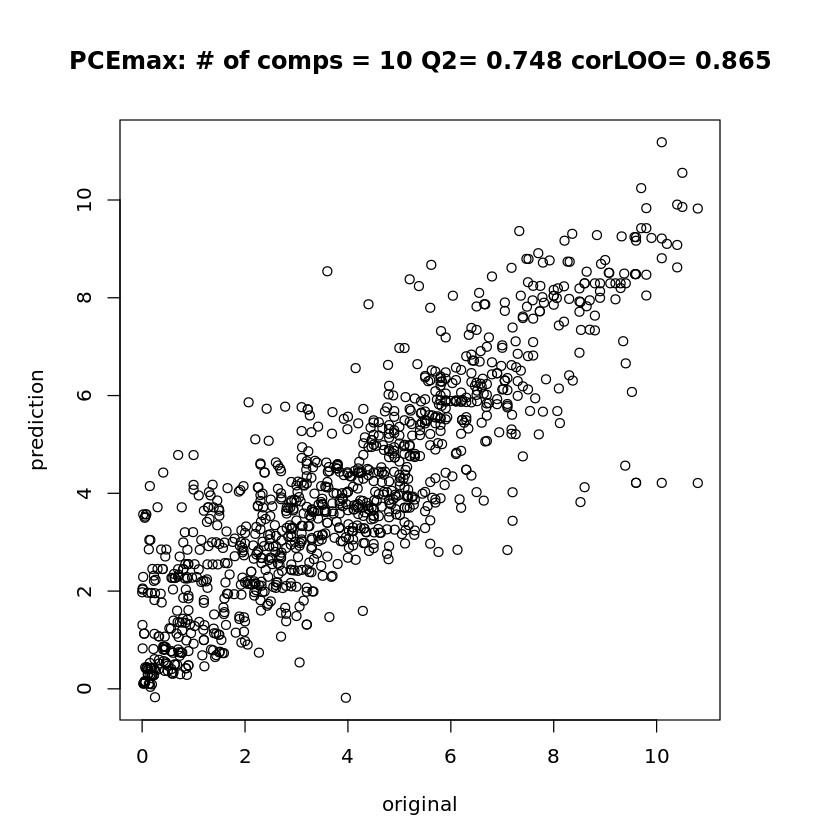

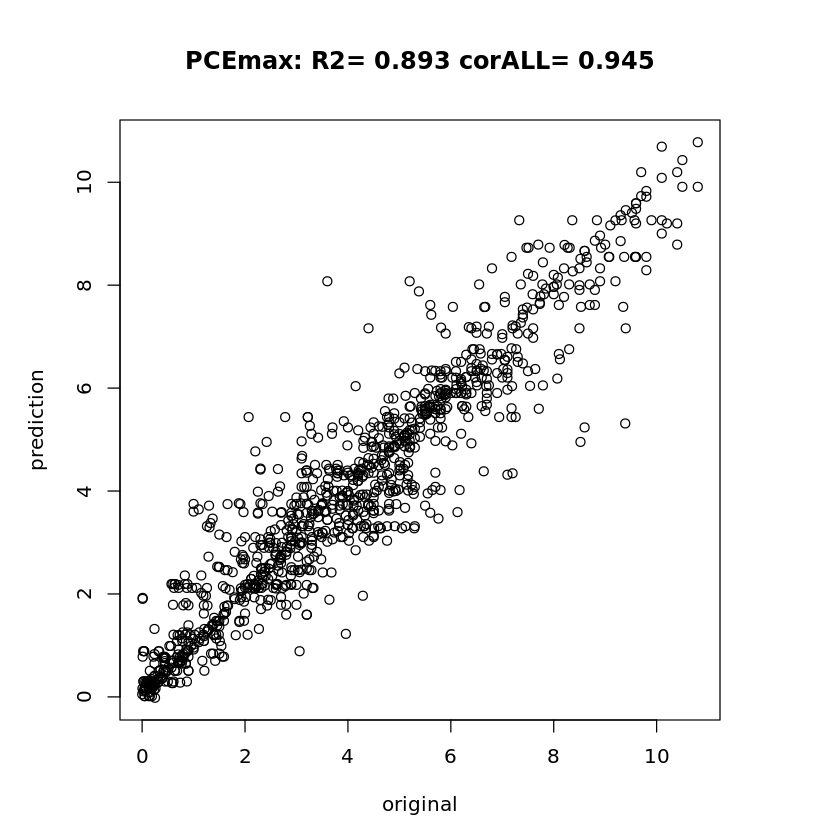

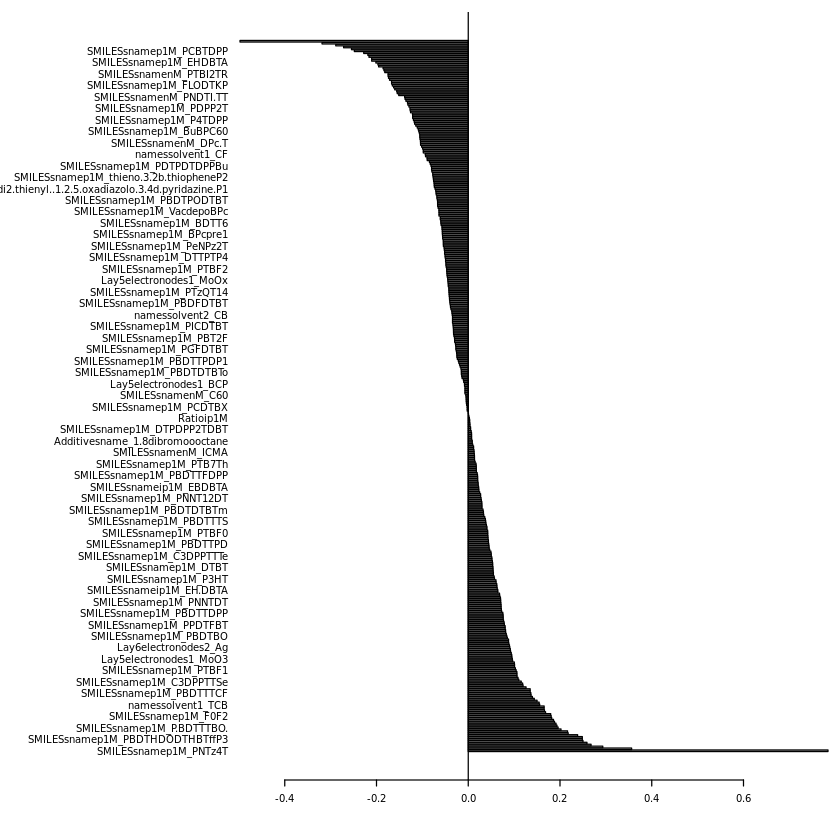

In [4]:
result1.pls<-plsr(Y~.,data=YXdata,scale=FALSE,validation="LOO")
names(result1.pls)
plspress<-result1.pls$validation$PRESS
ncomponent<-which.min(plspress)
#---[sum((dataUsed$Y-Ypred1)^2) == plspress]--------------------
Ypred1<-result1.pls$validation$pred[,,ncomponent]
#[5]--- Q2
tss<-sum((YXdata[,1]-mean(YXdata[,1]))^2)
Q2<-1-plspress/tss
mc<-which.max(Q2)
par(cex=1.0)
barplot(Q2[1:20],names.arg=1:20)
corLOO<-cor(YXdata[,1],Ypred1)
titleR<-paste0(yname,": # of comps = ",mc, " Q2= ",substring(max(Q2),1,5),
               " corLOO= ",substring(corLOO,1,5))
par(cex=1.0)
par(mar=c(5,5,5,5))
plot(YXdata[,1],Ypred1,xlab="original", ylab="prediction",main=titleR)
#[6]------------------------------------------
Ypred2<-predict(result1.pls,newdata=YXdata, ncomp = ncomponent)
rss<-sum((YXdata[,1]-Ypred2)^2)
R2<-1-rss/tss
CR<-cor(YXdata[,1],Ypred2)
titleR<-paste0(yname,": R2= ",substring(R2,1,5)," corALL= ",substring(CR,1,5))
par(cex=1.0)
par(mar=c(5,5,5,5))
plot(YXdata[,1],Ypred2,xlab="original",ylab="prediction",main=titleR)
#[7]---------------------------------------
par(cex=0.5)
par(mar=c(5,20,1,1))
corR<-sort(coefficients(result1.pls,ncomp=ncomponent)[,1,1],decreasing=TRUE)
barplot(corR,horiz=TRUE,las=1)
abline(v=0,lty=1)



In [11]:
fn<-paste0("Datapls",yname,".csv")
write.csv(corR,file=fn)

In [16]:
#チェック
#Ypred2
#aa2<-Ypred2[Ypred2>50]#予測値オーバー
#bb2<-which(Ypred2>50)
#aa2
#bb2
YXdata[,1]
aa3<-YXdata[,1][YXdata[,1]>1.5]#
bb3<-which(YXdata[,1]>1.5)
aa3
bb3

[1] 0.030 0.080 0.160 0.360 0.520 0.610 0.530 0.490 0.670 0.660 0.640 0.940
  [13] 0.980 0.020 0.450 0.480 0.470 0.470 0.520 0.450 0.140 0.620 0.590 0.800
  [25] 1.050 1.010 0.970 0.820 0.890 0.880 0.860 0.910 0.930 1.050 1.000 0.920
  [37] 0.780 0.650 0.830 0.910 0.920 1.060 0.780 1.030 0.970 0.930 1.030 1.010
  [49] 0.990 0.990 0.410 0.040 0.140 0.310 0.480 0.900 0.930 0.890 0.840 0.820
  [61] 0.480 0.620 0.490 0.600 0.600 0.620 0.570 0.640 0.660 0.610 0.650 0.630
  [73] 0.650 0.650 0.610 0.670 0.670 0.670 0.670 0.670 0.660 0.680 0.690 0.690
  [85] 0.730 0.700 0.660 0.690 0.690 0.680 0.680 0.670 0.550 0.440 0.450 0.700
  [97] 0.520 0.660 0.640 0.550 0.390 0.660 0.580 0.650 0.690 0.620 0.690 0.890
 [109] 0.880 0.870 0.890 0.880 0.910 0.900 0.910 0.890 0.880 0.880 0.900 0.860
 [121] 0.900 0.900 0.690 0.880 0.870 0.880 0.880 0.880 0.880 0.880 0.880 0.890
 [133] 0.500 0.560 0.580 0.560 0.580 0.900 0.966 0.419 0.499 0.602 0.746 0.739
 [145] 0.743 0.738 0.732 0.729 0.723 0.715 0.711 0.712 0.708 0.703 0.725 0.731
 [157] 0.730 0.729 0.719 0.720 0.716 0.708 0.712 0.708 0.708 0.691 0.725 0.703
 [169] 0.726 0.727 1.000 0.990 0.980 0.970 0.980 0.960 0.960 0.950 0.730 0.840
 [181] 0.710 0.810 0.710 0.820 0.930 0.730 0.830 0.930 0.830 0.760 0.740 0.830
 [193] 0.840 0.830 0.830 0.820 0.860 0.830 0.820 0.810 0.840 0.830 0.810 0.810
 [205] 0.810 0.800 0.830 0.820 0.820 0.820 0.810 0.820 0.810 0.780 0.820 0.820
 [217] 0.810 0.790 0.880 0.880 0.890 0.880 0.870 0.880 0.900 0.890 0.910 0.900
 [229] 0.890 0.890 0.880 0.870 0.870 0.900 0.900 0.890 1.050 1.000 1.070 0.400
 [241] 0.370 0.640 0.640 0.590 1.000 1.000 0.990 0.980 0.380 0.330 0.580 0.540
 [253] 0.610 0.600 0.530 0.890 0.660 0.640 0.350 0.640 0.610 0.630 0.640 0.770
 [265] 0.770 0.770 0.780 0.750 0.770 0.770 0.760 0.760 0.760 0.730 0.760 0.780
 [277] 0.760 0.780 0.770 0.800 0.750 0.760 0.770 0.770 0.810 0.800 0.780 0.720
 [289] 0.760 0.770 0.620 0.700 0.760 0.680 0.930 0.950 0.910 0.670 0.790 0.915
 [301] 0.920 0.935 0.940 0.945 0.945 0.900 0.915 0.650 0.610 0.640 0.660 0.610
 [313] 0.540 0.700 0.730 0.790 0.790 0.770 0.770 0.800 0.800 0.770 0.770 0.760
 [325] 0.750 0.750 0.740 0.740 0.760 0.740 0.770 0.760 0.730 0.810 0.690 0.760
 [337] 0.740 0.810 0.790 0.780 0.780 0.860 0.540 0.640 0.730 0.830 0.740 0.800
 [349] 0.760 0.820 0.810 0.860 0.780 0.810 0.780 0.780 0.760 0.740 0.740 0.890
 [361] 0.690 0.760 0.970 0.700 0.730 0.790 0.710 0.850 0.700 0.550 0.500 0.800
 [373] 0.880 0.950 0.900 0.860 0.710 0.960 0.850 0.820 0.660 0.910 1.020 0.600
 [385] 0.640 0.800 0.560 0.620 0.940 0.680 0.700 0.390 0.360 0.380 0.420 0.410
 [397] 0.410 0.680 0.650 0.680 0.680 0.800 0.800 0.800 0.740 0.730 0.720 0.730
 [409] 0.790 0.790 1.790 1.790 0.800 0.800 0.800 0.800 0.760 0.780 0.780 0.770
 [421] 0.680 0.760 0.760 0.760 0.790 0.740 0.760 0.440 0.380 0.400 0.900 0.570
 [433] 0.690 0.640 0.610 0.650 0.670 0.510 0.560 0.560 0.550 0.460 0.470 0.370
 [445] 0.560 0.580 0.700 0.970 0.910 0.930 0.910 0.450 0.590 0.790 0.410 0.580
 [457] 0.760 0.900 0.880 0.850 0.600 0.560 0.750 0.680 0.370 0.220 0.550 0.920
 [469] 0.920 0.920 0.900 0.920 0.850 0.860 0.860 0.850 0.790 0.750 0.740 0.720
 [481] 0.820 0.820 0.800 0.850 0.840 0.820 0.900 0.920 0.890 0.690 0.650 0.630
 [493] 0.630 0.750 0.790 0.900 0.830 0.810 0.810 0.760 0.730 0.720 0.780 0.780
 [505] 0.780 0.780 0.710 0.710 0.710 0.700 0.760 0.690 0.690 0.620 0.610 0.610
 [517] 0.580 0.630 0.660 0.560 0.590 0.820 0.800 0.810 0.820 0.750 0.780 0.810
 [529] 0.810 0.750 0.770 0.830 0.810 0.770 0.780 0.760 0.800 0.750 0.760 0.870
 [541] 0.880 0.840 0.830 0.840 0.810 0.880 0.870 0.810 0.810 0.850 0.860 0.840
 [553] 0.850 0.870 0.850 0.800 0.820 0.850 0.810 0.860 0.870 0.820 0.840 0.780
 [565] 0.800 0.860 0.800 0.840 0.880 0.840 0.810 0.810 0.790 0.820 0.860 0.730
 [577] 0.850 0.820 0.840 0.820 0.880 0.890 0.800 0.810 0.880 0.880 0.870 0.860
 [589] 0.830 0.850 0.860 0.850 0.580 0.600 0.740 0.760 0.680 0.620 0.720 0.740
 [601] 0.660 0.807 0.813 0.809 0.890 0.870 0.810 0.81

[1] 1.79 1.79

[1] 411 412

In [17]:
aa<-c(411,412)

YXdata<-YXXdata[-c(aa),] 
YXdata
dim(YXdata)

,Y,amountAditive,cycle,RatioinM,Ratioip1M,Ratioip2M,Ratiop2M,THFSVAafetrI,THFSVAafetrN,Lay2Mname_,...,namessolvent1_DCM,namessolvent1_oDCB,namessolvent1_TCB,namessolvent1_THF,namessolvent2_,namessolvent2_CB,namessolvent2_CF,namessolvent2_DIO,namessolvent2_oDCB,namessolvent2_TCB
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.03,-0.3723163,-0.05358002,-0.180825,-0.1738466,-0.06923165,-0.04704442,-0.0758827,-0.03090485,-0.4826933,...,10.73420595,-0.8245774,-0.1076249,-0.03090485,0.3372255,-0.0758827,-0.03090485,-0.04372697,-0.3175688,-0.04372697
2,0.08,-0.3723163,18.64584731,-0.180825,-0.1738466,-0.06923165,-0.04704442,-0.0758827,-0.03090485,-0.4826933,...,10.73420595,-0.8245774,-0.1076249,-0.03090485,0.3372255,-0.0758827,-0.03090485,-0.04372697,-0.3175688,-0.04372697
3,0.16,-0.3723163,18.64584731,-0.180825,-0.1738466,-0.06923165,-0.04704442,-0.0758827,-0.03090485,-0.4826933,...,10.73420595,-0.8245774,-0.1076249,-0.03090485,0.3372255,-0.0758827,-0.03090485,-0.04372697,-0.3175688,-0.04372697
4,0.36,-0.3723163,18.64584731,-0.180825,-0.1738466,-0.06923165,-0.04704442,-0.0758827,-0.03090485,-0.4826933,...,10.73420595,-0.8245774,-0.1076249,-0.03090485,0.3372255,-0.0758827,-0.03090485,-0.04372697,-0.3175688,-0.04372697
5,0.52,-0.3723163,-0.05358002,-0.180825,-0.1738466,-0.06923165,-0.04704442,-0.0758827,-0.03090485,-0.4826933,...,-0.09307115,-0.8245774,-0.1076249,-0.03090485,0.3372255,-0.0758827,-0.03090485,-0.04372697,-0.3175688,-0.04372697
6,0.61,-0.3723163,-0.05358002,-0.180825,-0.1738466,-0.06923165,-0.04704442,-0.0758827,-0.03090485,-0.4826933,...,-0.09307115,-0.8245774,-0.1076249,-0.03090485,0.3372255,-0.0758827,-0.03090485,-0.04372697,-0.3175688,-0.04372697
7,0.53,-0.3723163,-0.05358002,-0.180825,-0.1738466,-0.06923165,-0.04704442,-0.0758827,-0.03090485,-0.4826933,...,-0.09307115,-0.8245774,-0.1076249,-0.03090485,0.3372255,-0.0758827,-0.03090485,-0.04372697,-0.3175688,-0.04372697
8,0.49,-0.3723163,-0.05358002,-0.180825,-0.1738466,-0.06923165,-0.04704442,-0.0758827,-0.03090485,-0.4826933,...,-0.09307115,-0.8245774,-0.1076249,-0.03090485,0.3372255,-0.0758827,-0.03090485,-0.04372697,-0.3175688,-0.04372697
9,0.67,-0.3723163,-0.05358002,-0.180825,-0.1738466,-0.06923165,-0.04704442,-0.0758827,-0.03090485,-0.4826933,...,-0.09307115,-0.8245774,-0.1076249,-0.03090485,0.3372255,-0.0758827,-0.03090485,-0.04372697,-0.3175688,-0.04372697


[1] 1045  377

[1] "coefficients"    "scores"          "loadings"        "loading.weights"
 [5] "Yscores"         "Yloadings"       "projection"      "Xmeans"         
 [9] "Ymeans"          "fitted.values"   "residuals"       "Xvar"           
[13] "Xtotvar"         "fit.time"        "ncomp"           "method"         
[17] "validation"      "call"            "terms"           "model"

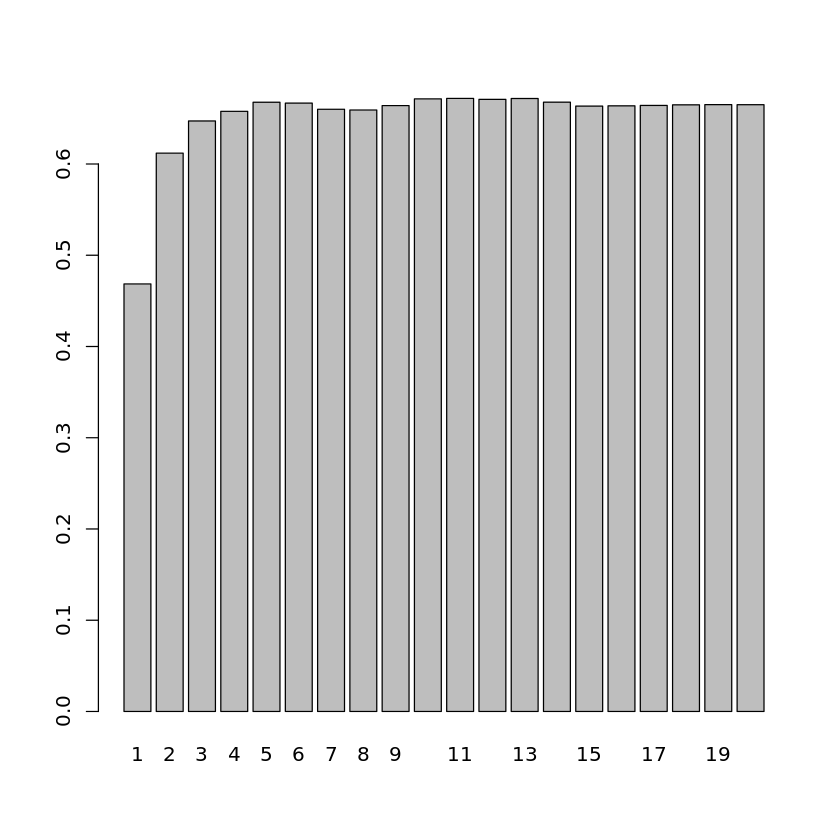

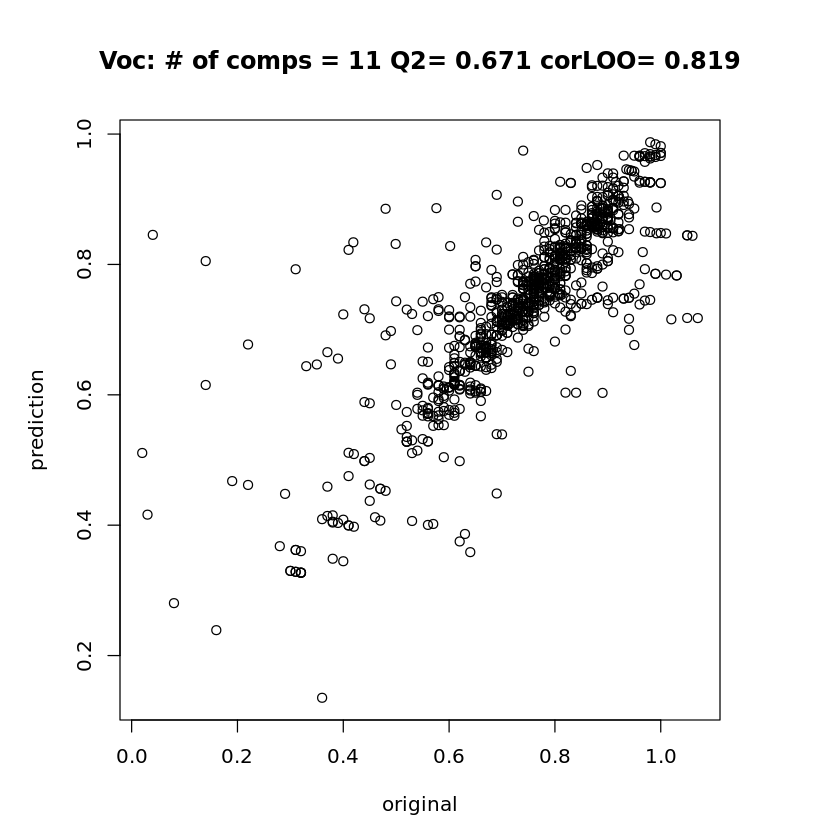

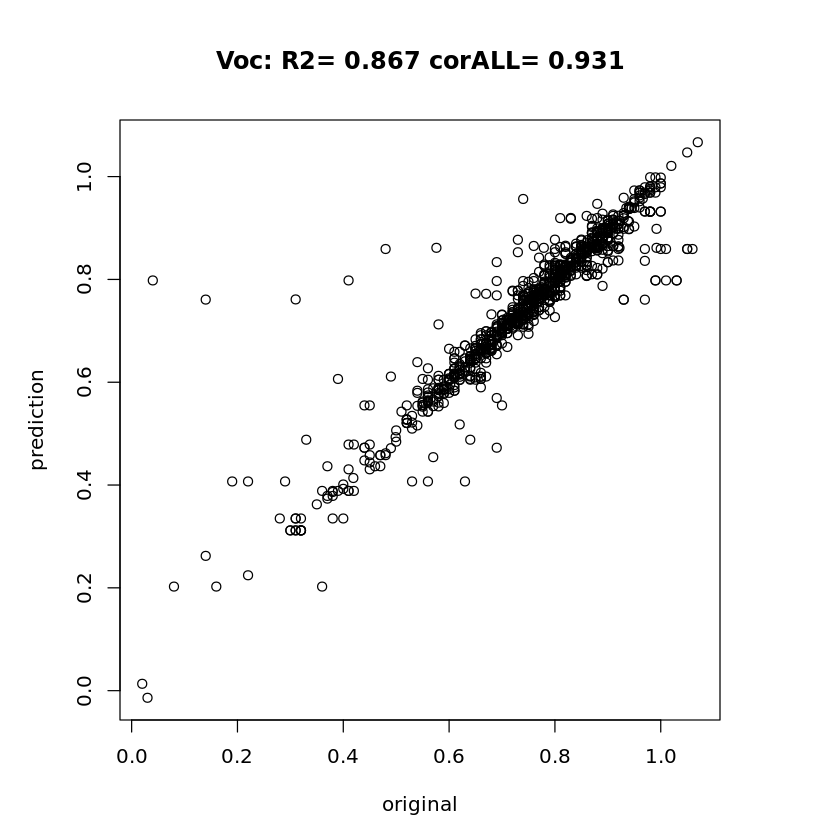

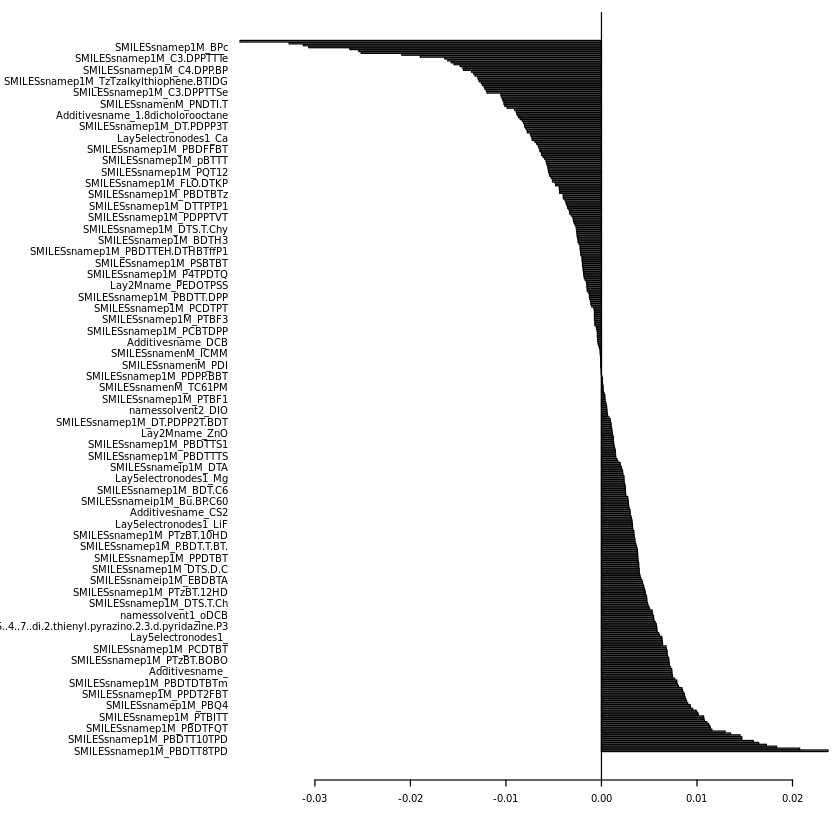

In [18]:
result1.pls<-plsr(Y~.,data=YXdata,scale=FALSE,validation="LOO")
names(result1.pls)
plspress<-result1.pls$validation$PRESS
ncomponent<-which.min(plspress)
#---[sum((dataUsed$Y-Ypred1)^2) == plspress]--------------------
Ypred1<-result1.pls$validation$pred[,,ncomponent]
#[5]--- Q2
tss<-sum((YXdata[,1]-mean(YXdata[,1]))^2)
Q2<-1-plspress/tss
mc<-which.max(Q2)
par(cex=1.0)
barplot(Q2[1:20],names.arg=1:20)
corLOO<-cor(YXdata[,1],Ypred1)
titleR<-paste0(yname,": # of comps = ",mc, " Q2= ",substring(max(Q2),1,5),
               " corLOO= ",substring(corLOO,1,5))
par(cex=1.0)
par(mar=c(5,5,5,5))
plot(YXdata[,1],Ypred1,xlab="original", ylab="prediction",main=titleR)
#[6]------------------------------------------
Ypred2<-predict(result1.pls,newdata=YXdata, ncomp = ncomponent)
rss<-sum((YXdata[,1]-Ypred2)^2)
R2<-1-rss/tss
CR<-cor(YXdata[,1],Ypred2)
titleR<-paste0(yname,": R2= ",substring(R2,1,5)," corALL= ",substring(CR,1,5))
par(cex=1.0)
par(mar=c(5,5,5,5))
plot(YXdata[,1],Ypred2,xlab="original",ylab="prediction",main=titleR)
#[7]---------------------------------------
par(cex=0.5)
par(mar=c(5,20,1,1))
corR<-sort(coefficients(result1.pls,ncomp=ncomponent)[,1,1],decreasing=TRUE)
barplot(corR,horiz=TRUE,las=1)
abline(v=0,lty=1)



In [19]:
fn<-paste0("Datapls",yname,".csv")
write.csv(corR,file=fn)

In [ ]:
YXdata<-dataYXXdata[-c(bb),]
dim(YXdata)

In [ ]:
#----------------------------------------------------------------
result1.pls<-plsr(Y~.,data=YXdata,scale=FALSE,validation="LOO")
names(result1.pls)
plspress<-result1.pls$validation$PRESS
ncomponent<-which.min(plspress)
#---[sum((dataUsed$Y-Ypred1)^2) == plspress]--------------------
Ypred1<-result1.pls$validation$pred[,,ncomponent]
#[5]--- Q2
tss<-sum((YXdata[,1]-mean(YXdata[,1]))^2)
Q2<-1-plspress/tss
mc<-which.max(Q2)
par(cex=1.0)
barplot(Q2[1:20],names.arg=1:20)
corLOO<-cor(YXdata[,1],Ypred1)
titleR<-paste0(yname,": # of comps = ",mc, " Q2= ",substring(max(Q2),1,5),
               " corLOO= ",substring(corLOO,1,5))
par(cex=1.0)
par(mar=c(5,5,5,5))
plot(YXdata[,1],Ypred1,xlab="original", ylab="prediction",main=titleR)
#[6]------------------------------------------
Ypred2<-predict(result1.pls,newdata=YXdata, ncomp = ncomponent)
rss<-sum((YXdata[,1]-Ypred2)^2)
R2<-1-rss/tss
CR<-cor(YXdata[,1],Ypred2)
titleR<-paste0(yname,": R2= ",substring(R2,1,5)," corALL= ",substring(CR,1,5))
par(cex=1.0)
par(mar=c(5,5,5,5))
plot(YXdata[,1],Ypred2,xlab="original",ylab="prediction",main=titleR)
#[7]---------------------------------------
par(cex=0.5)
par(mar=c(5,20,1,1))
corR<-sort(coefficients(result1.pls,ncomp=ncomponent)[,1,1],decreasing=TRUE)
barplot(corR,horiz=TRUE,las=1)
abline(v=0,lty=1)

[1] 1048   42

,Y,Abandp1Mfilm1,Lay2thickness,Aonsetp1Mfilm,MwkDap1M,LUMOp1M,MnkDap1M,VolRatioS1,Mmonomerp1M,Lay6thickness,HOMOp1M,ALthickness,Egoptp1M,Lay5thickness,PDIp1M,RationM,Ratiop1M,TApn
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
317,13.02,-1.3913378,0.7356147,1.45346804,0.11509044,0.56673356,-0.22057875,-3.7770530,-0.9913419,1.393121,0.18464527,-0.1919181,-1.47528696,-1.8206597,0.6914765,0.2494893,-0.2494893,-1.1671687
318,14.02,-1.3913378,0.7356147,1.45346804,0.70838411,0.56673356,2.29636011,-3.7770530,-0.9913419,1.393121,0.18464527,-0.1919181,-1.47528696,-1.8206597,-0.4544810,0.2494893,-0.2494893,-1.1671687
319,12.16,-1.3913378,0.7356147,1.45346804,2.32059517,0.56673356,0.60295953,-3.7770530,-0.9913419,1.393121,0.18464527,-0.1919181,-1.47528696,-1.8206597,2.0920911,0.2494893,-0.2494893,-1.1671687
320,11.63,-1.3913378,0.7356147,1.45346804,3.94570392,0.56673356,1.01472867,-3.7770530,-0.9913419,1.393121,0.18464527,-0.1919181,-1.47528696,-1.8206597,3.3653772,0.2494893,-0.2494893,-1.1671687
479,12.31,-1.0665527,-1.3374813,0.22963347,1.82139014,-1.75334889,2.06988708,0.2604864,1.2387843,-0.406327,-1.93115793,-0.6746331,-0.33193957,-0.1272768,1.2899209,-1.2474464,1.2474464,-1.1671687
480,12.24,-1.0665527,-1.3374813,0.22963347,1.82139014,-1.75334889,2.06988708,0.2604864,1.2387843,-0.406327,-1.93115793,-0.6263616,-0.33193957,-0.1272768,1.2899209,0.2494893,-0.2494893,-1.1671687
481,9.86,-1.0665527,-1.3374813,0.22963347,1.82139014,-1.75334889,2.06988708,0.2604864,1.2387843,-0.406327,-1.93115793,-0.5539544,-0.33193957,-0.1272768,1.2899209,1.2474464,-1.2474464,-1.1671687
491,8.35,-1.0665527,-1.3374813,0.22963347,1.82139014,-1.75334889,2.06988708,0.2604864,1.2387843,-0.406327,-1.93115793,-0.6746331,-0.33193957,-0.1272768,1.2899209,0.2494893,-0.2494893,-1.1671687
492,11.02,-1.0665527,-1.3374813,0.22963347,1.82139014,-1.75334889,2.06988708,0.2604864,1.2387843,-0.406327,-1.93115793,-0.5539544,-0.33193957,-0.1272768,1.2899209,0.2494893,-0.2494893,-1.1671687


[1] 62 18

[1] "coefficients"    "scores"          "loadings"        "loading.weights"
 [5] "Yscores"         "Yloadings"       "projection"      "Xmeans"         
 [9] "Ymeans"          "fitted.values"   "residuals"       "Xvar"           
[13] "Xtotvar"         "fit.time"        "ncomp"           "method"         
[17] "validation"      "call"            "terms"           "model"

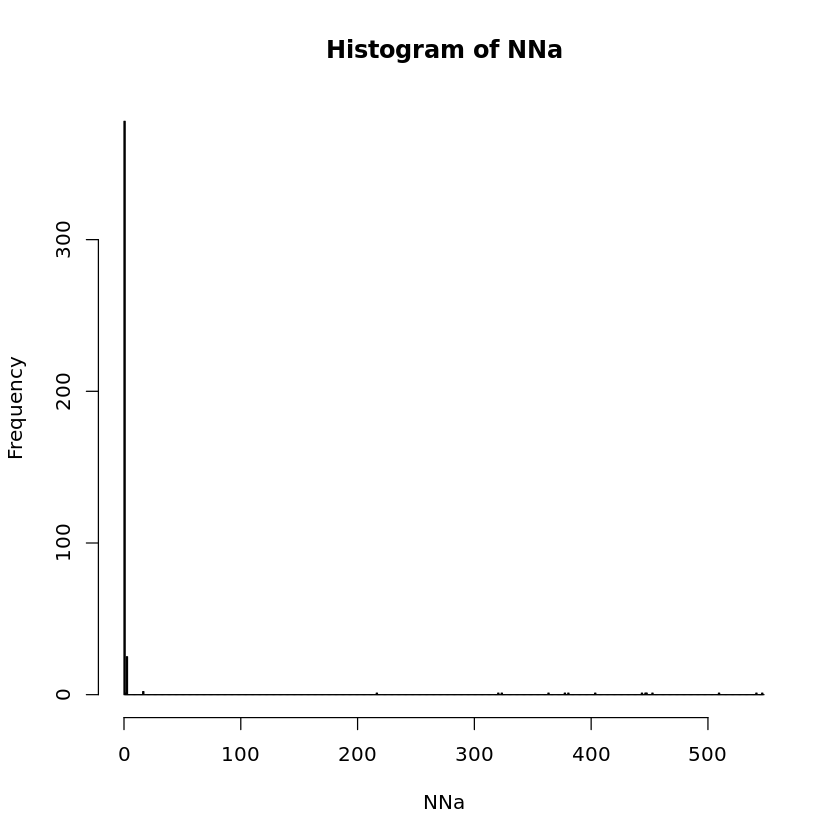

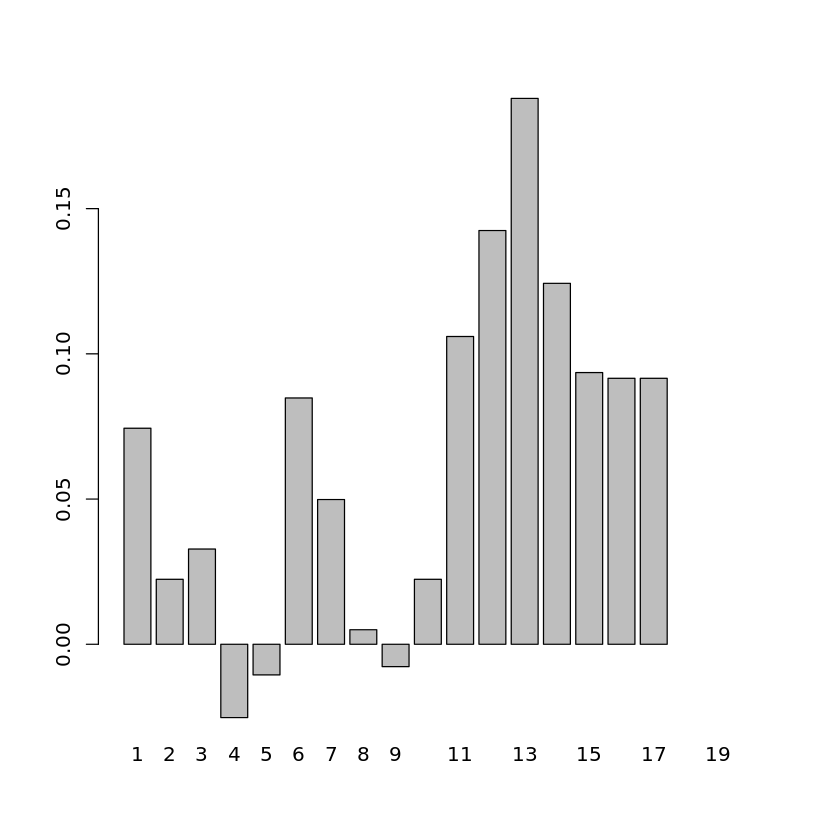

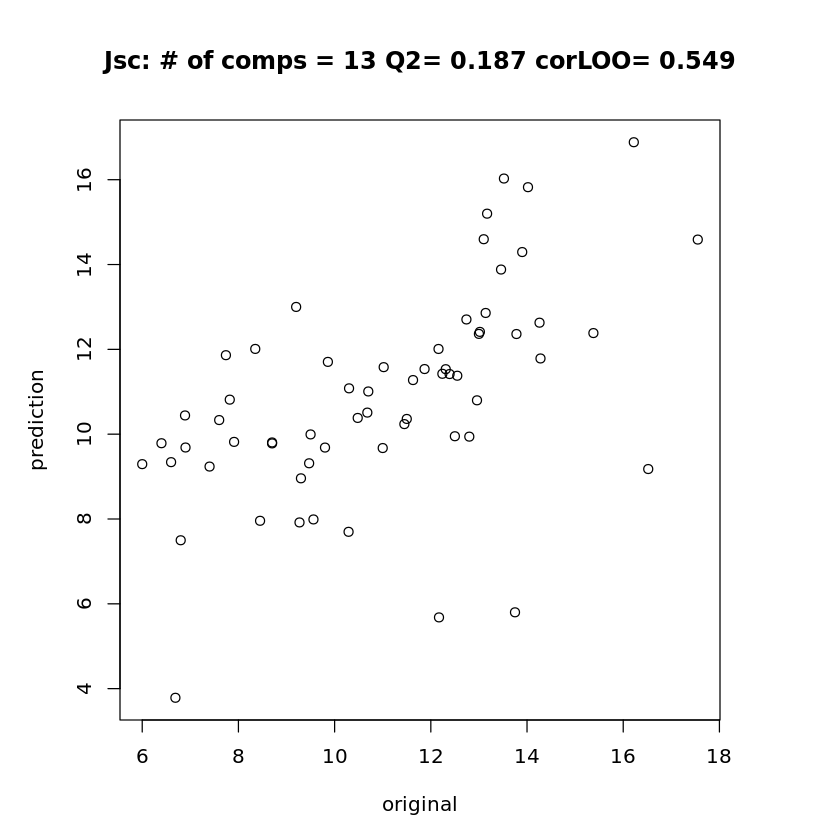

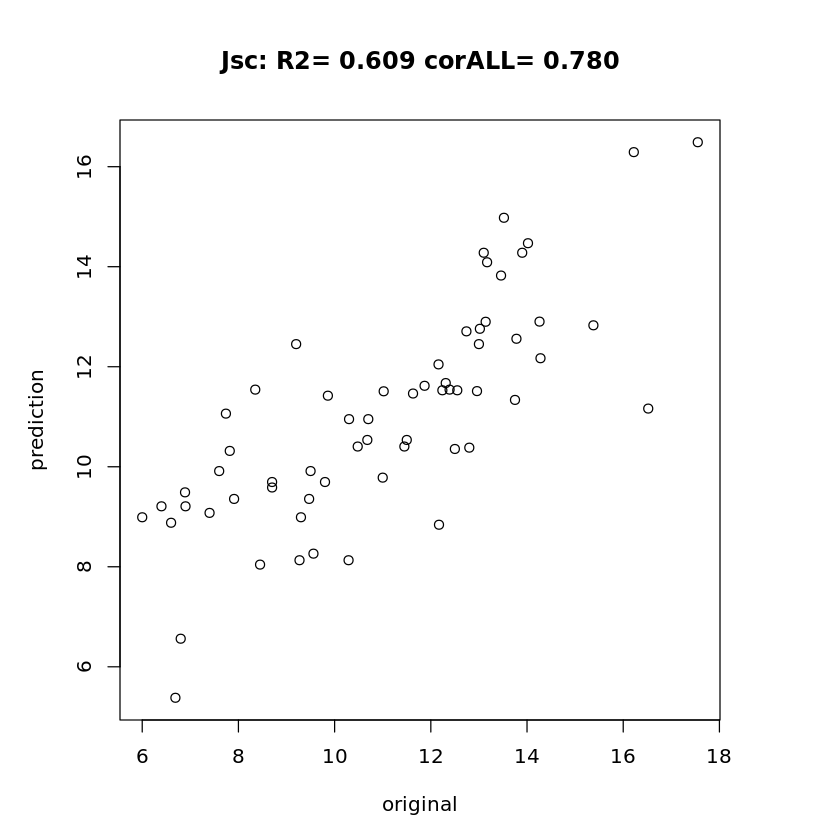

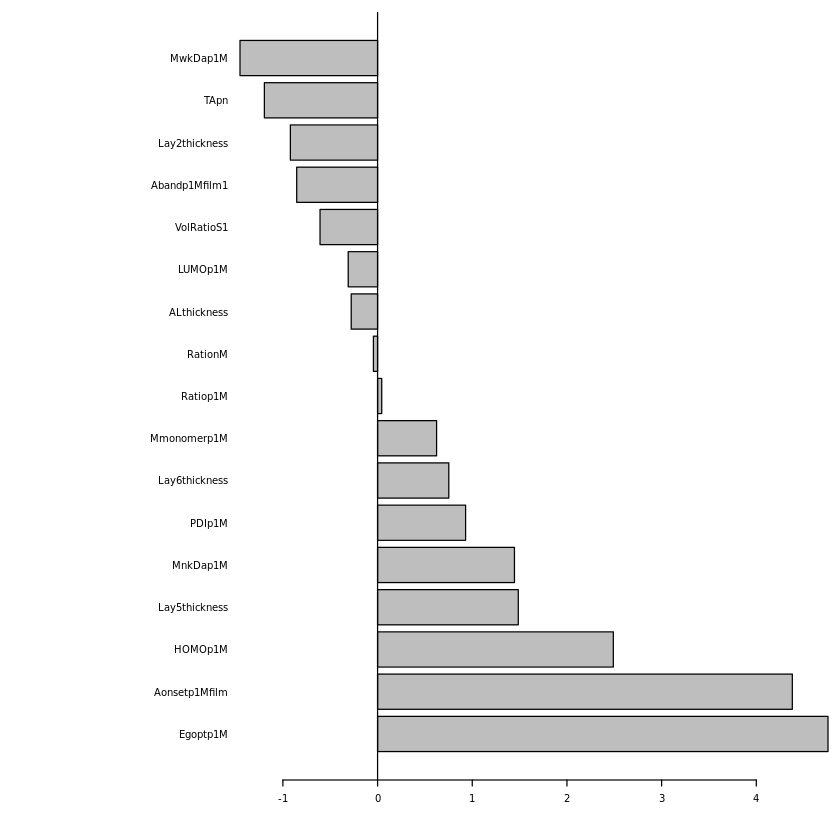

In [44]:
#[1]
ifname <- "DataMerge20211213.csv"
readData <- read.delim(ifname, header=T,sep=",",row.names=1,as.is=TRUE,strip.white=FALSE)
nf1<-dim(readData)[2]
charaCheck<-rep(FALSE,nf1)
for(i in 1:nf1){
  charaCheck[i]<-!is.character(readData[,i])
}
readData2<-readData[,charaCheck]
#[2]
yname<-"Jsc"     #"Jsc","Voc","FF","PCEmax"
Y<-readData2[,yname]
rmlist<-c("Jsc","Voc","FF","PCEmax","PCEcal", "PCEdiff", "PCEave")
collist<-colnames(readData2)
Xnames<-setdiff(collist, rmlist)
X<-readData2[,c(Xnames)]
#---
Nadata<-is.na(X)

NNa<-apply(Nadata,2,sum)
mNNA<-max(NNa)
hist(NNa,breaks=seq(0,mNNA+1,1))

XX<-X[,NNa>=2] #~100 変化
dim(XX)
#---
dMerge<-data.frame(Y,XX)
Nadata<-na.omit(dMerge)
#[3]
sdcheck<-apply(Nadata,2,sd)
TF<-(sdcheck!=0)
ssd<-scale(Nadata[,TF])
ssd[,1]<-Nadata[,1]
#[4]
YXXdata<-data.frame(ssd)
#----------------------------------------------------------------
aa<-c(567,574,575,576,577,585,586,587)

YXdata<-YXXdata[-c(aa),] #
YXdata
dim(YXdata)
result1.pls<-plsr(Y~.,data=YXdata,scale=FALSE,validation="LOO")
names(result1.pls)
plspress<-result1.pls$validation$PRESS
ncomponent<-which.min(plspress)
#---[sum((dataUsed$Y-Ypred1)^2) == plspress]--------------------
Ypred1<-result1.pls$validation$pred[,,ncomponent]
#[5]--- Q2
tss<-sum((YXdata[,1]-mean(YXdata[,1]))^2)
Q2<-1-plspress/tss
mc<-which.max(Q2)
par(cex=1.0)
barplot(Q2[1:20],names.arg=1:20)
corLOO<-cor(YXdata[,1],Ypred1)
titleR<-paste0(yname,": # of comps = ",mc, " Q2= ",substring(max(Q2),1,5),
               " corLOO= ",substring(corLOO,1,5))
par(cex=1.0)
par(mar=c(5,5,5,5))
plot(YXdata[,1],Ypred1,xlab="original", ylab="prediction",main=titleR)
#[6]------------------------------------------
Ypred2<-predict(result1.pls,newdata=YXdata, ncomp = ncomponent)
rss<-sum((YXdata[,1]-Ypred2)^2)
R2<-1-rss/tss
CR<-cor(YXdata[,1],Ypred2)
titleR<-paste0(yname,": R2= ",substring(R2,1,5)," corALL= ",substring(CR,1,5))
par(cex=1.0)
par(mar=c(5,5,5,5))
plot(YXdata[,1],Ypred2,xlab="original",ylab="prediction",main=titleR)
#[7]---------------------------------------
par(cex=0.5)
par(mar=c(5,20,1,1))
corR<-sort(coefficients(result1.pls,ncomp=ncomponent)[,1,1],decreasing=TRUE)
barplot(corR,horiz=TRUE,las=1)
abline(v=0,lty=1)

